<a href="https://colab.research.google.com/github/franciscosrcoelho-coder/Google-Colab/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Model

np.random.seed(123)
tf.random.set_seed(123)

In [95]:
!pip install -U scikit-learn

In [96]:
from sklearn.metrics import mean_absolute_percentage_error

In [97]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_absolute_percentage_error, \
  mean_absolute_error, r2_score, mean_squared_error

In [98]:
url = 'https://raw.githubusercontent.com/franciscosrcoelho-coder/Google-Colab/refs/heads/main/Data%20Science%20Applications%20Project%20Data.csv'
df = pd.read_csv(url)

In [99]:
# add the date attribute starting from Jan 2000, with a monthly frequency
df['year_month'] = pd.date_range(start='1/2016', end='4/2026', freq='M',
                                    inclusive='both')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123 entries, 0 to 122
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Month        123 non-null    object        
 1   Consumption  123 non-null    int64         
 2   year_month   123 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 3.0+ KB


In [100]:
df=df.drop('Month',axis=1)

In [101]:
df.set_index('year_month', inplace=True)

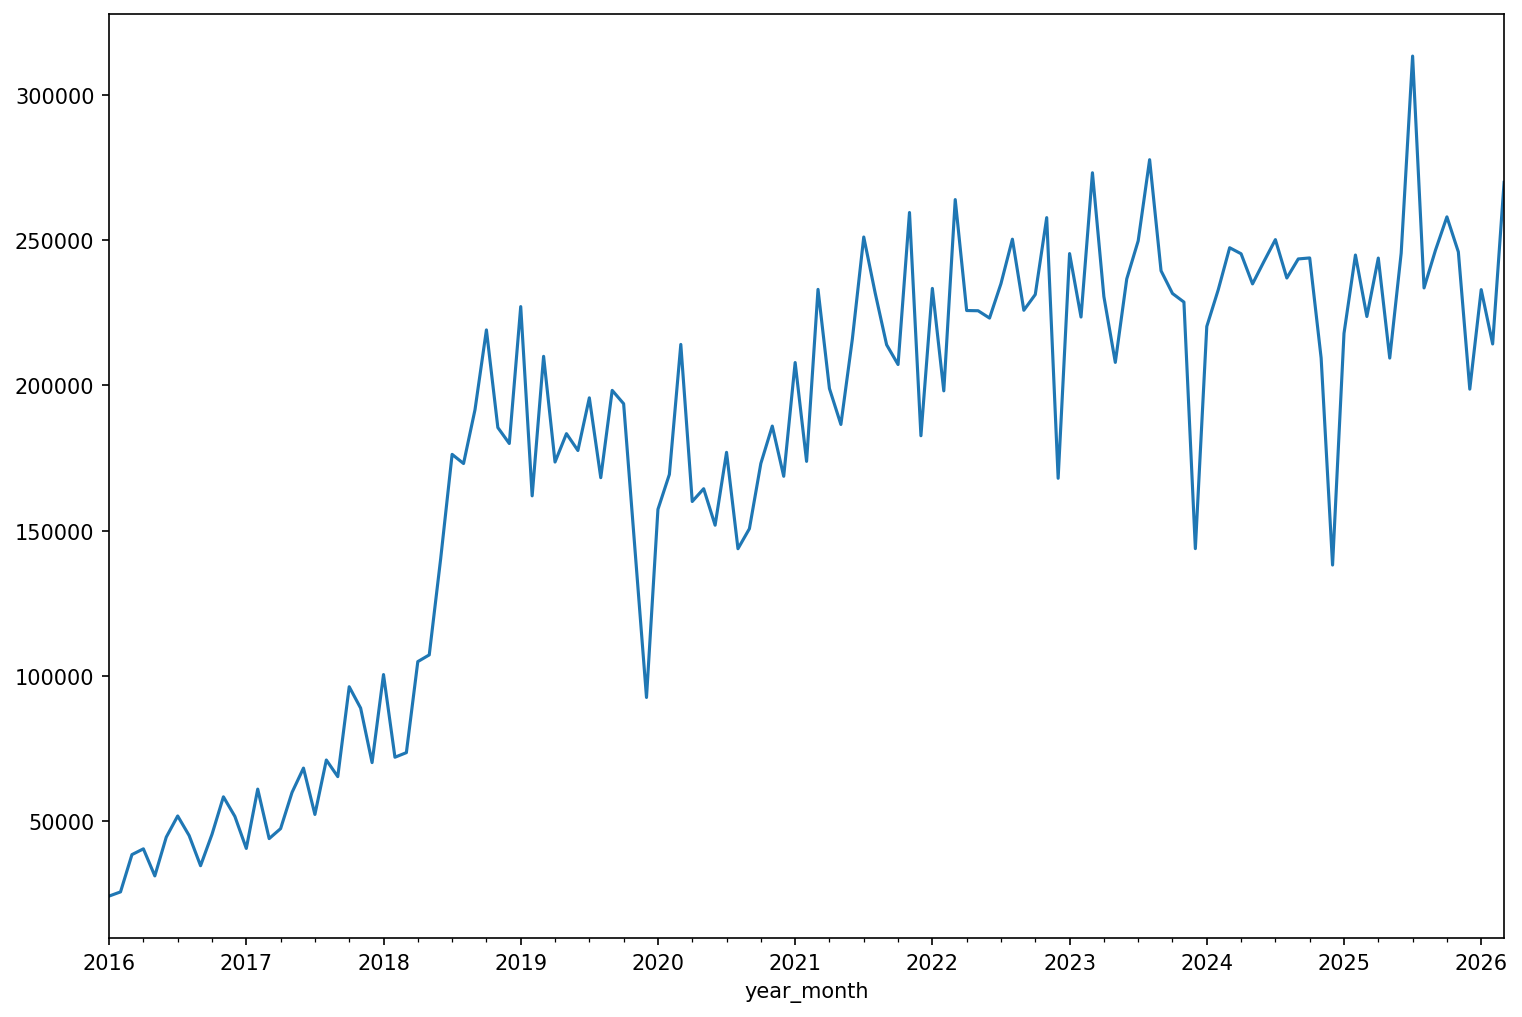

In [102]:
plt.figure(figsize=(12,8),dpi=150)
df['Consumption'].plot();

In [103]:
df.head()

,Consumption
year_month,
2016-01-31,24273
2016-02-29,25715
2016-03-31,38543
2016-04-30,40524
2016-05-31,31222


In [104]:
Ntest = 12
train = df.iloc[:-Ntest]
test = df.iloc[-Ntest:]

In [105]:
# boolean series to index df rows
train_idx = df.index <= train.index[-1]
test_idx = df.index > train.index[-1]

In [106]:
df['DiffConsumption'] = df['Consumption'].diff()

In [107]:
# Make supervised dataset
series = df['DiffConsumption'].dropna().to_numpy()

T = 10
X = []
Y = []
for t in range(len(series) - T):
  x = series[t:t+T]
  X.append(x)
  y = series[t+T]
  Y.append(y)

X = np.array(X).reshape(-1, T)
Y = np.array(Y)
N = len(X)
print("X.shape", X.shape, "Y.shape", Y.shape)

X.shape (112, 10) Y.shape (112,)


In [108]:
Xtrain, Ytrain = X[:-Ntest], Y[:-Ntest]
Xtest, Ytest = X[-Ntest:], Y[-Ntest:]

# **ANN**

In [109]:
# Basic ANN
i = Input(shape=(T,))
x = Dense(32, activation='relu')(i)
x = Dense(1)(x)
model = Model(i, x)

In [110]:
model.compile(
  loss='mse',
  optimizer='adam',
)

In [111]:
r = model.fit(
  Xtrain,
  Ytrain,
  epochs=150,
  validation_data=(Xtest, Ytest)
)

Epoch 1/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 154ms/step - loss: 1671547648.0000 - val_loss: 2712873728.0000
Epoch 2/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - loss: 1588102144.0000 - val_loss: 2616148224.0000
Epoch 3/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 1521880576.0000 - val_loss: 2528912640.0000
Epoch 4/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - loss: 1462482432.0000 - val_loss: 2449105664.0000
Epoch 5/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 136ms/step - loss: 1408975360.0000 - val_loss: 2377550848.0000
Epoch 6/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 1361089024.0000 - val_loss: 2312701952.0000
Epoch 7/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 137ms/step - loss: 1318368896.0000 - val_loss: 2253797632.0000
Epoch 8/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - loss: 1280071808.0000 - val_loss: 2199876352.0000
Epoch 9/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 133ms/step - loss: 1245605888.0000 - val_loss: 2149811968.0000
Epoch 10/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 154ms/step - loss: 1214492288.0000

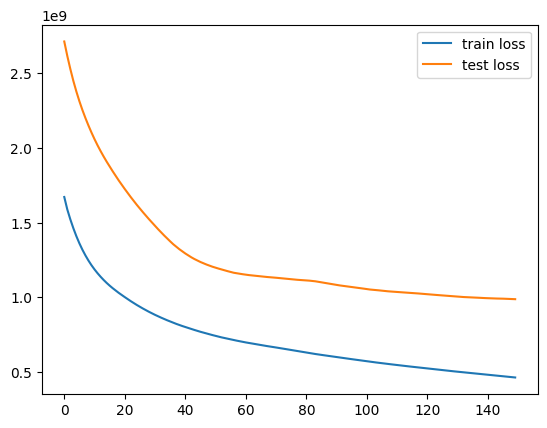

In [112]:
plt.plot(r.history['loss'], label='train loss')
plt.plot(r.history['val_loss'], label='test loss')
plt.legend();

In [113]:
train_idx[:T+1] = False # first T+1 values are not predictable

In [114]:
Ptrain = model.predict(Xtrain).flatten()
Ptest = model.predict(Xtest).flatten()

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


In [115]:
# Store diff predictions
df.loc[train_idx, 'Diff ANN Train Prediction'] = Ptrain
df.loc[test_idx, 'Diff ANN Test Prediction'] = Ptest

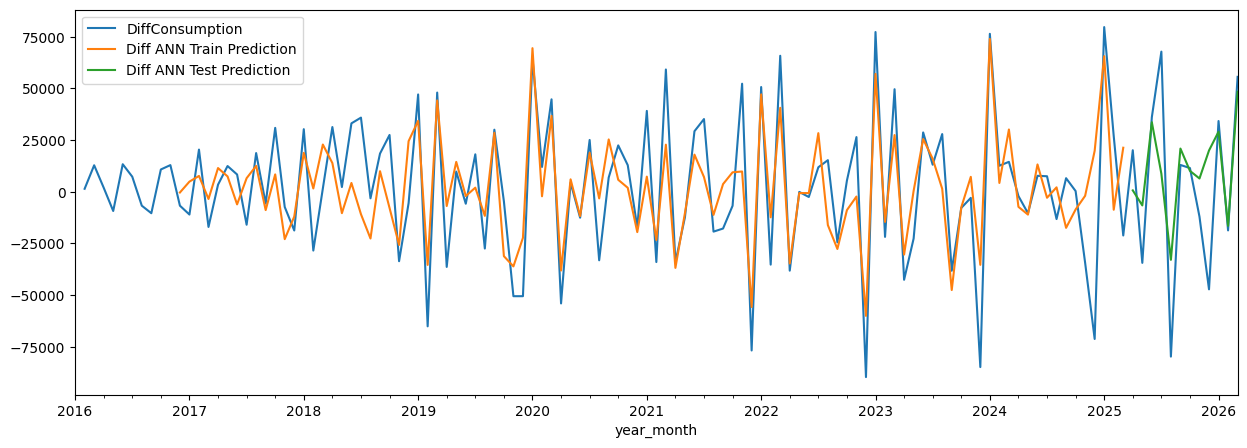

In [116]:
cols = ['DiffConsumption',
        'Diff ANN Train Prediction',
        'Diff ANN Test Prediction']
df[cols].plot(figsize=(15, 5));

In [117]:
# Needed to compute un-differenced predictions
df['ShiftConsumption'] = df['Consumption'].shift(1)
prev = df['ShiftConsumption']

In [118]:
# Last-known train value
last_train = train.iloc[-1]['Consumption']

In [119]:
# 1-step forecast
df.loc[train_idx, '1step_train'] = prev[train_idx] + Ptrain
df.loc[test_idx, '1step_test'] = prev[test_idx] + Ptest

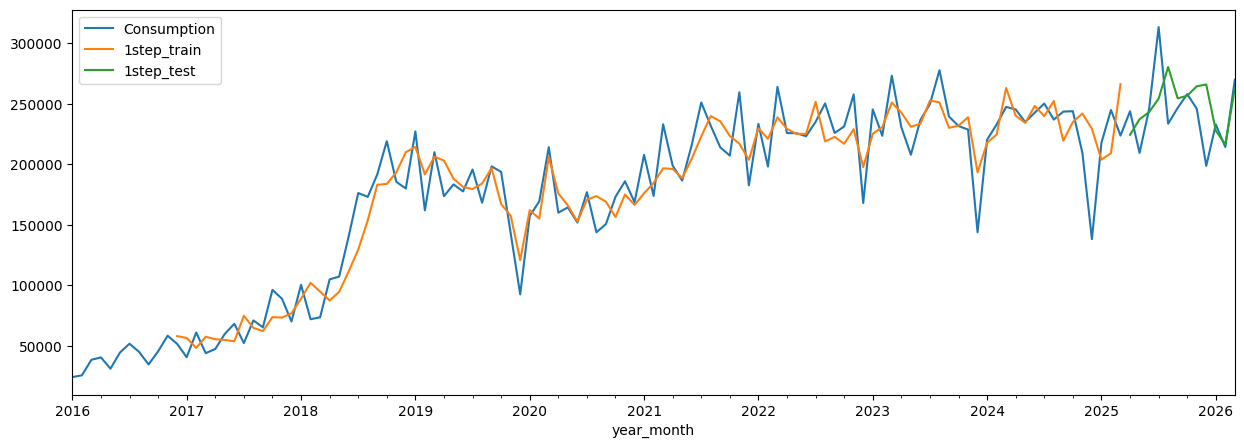

In [120]:
# plot 1-step forecast
df[['Consumption', '1step_train', '1step_test']].plot(figsize=(15, 5));

In [121]:
# multi-step forecast
multistep_predictions = []

# first test input
last_x = Xtest[0]

while len(multistep_predictions) < Ntest:
  p = model.predict(last_x.reshape(1, -1))[0]

  # update the predictions list
  multistep_predictions.append(p)

  # make the new input
  last_x = np.roll(last_x, -1)
  last_x[-1] = p

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


In [122]:
# save multi-step forecast to dataframe
df.loc[test_idx, 'multistep'] = last_train + np.cumsum(multistep_predictions)

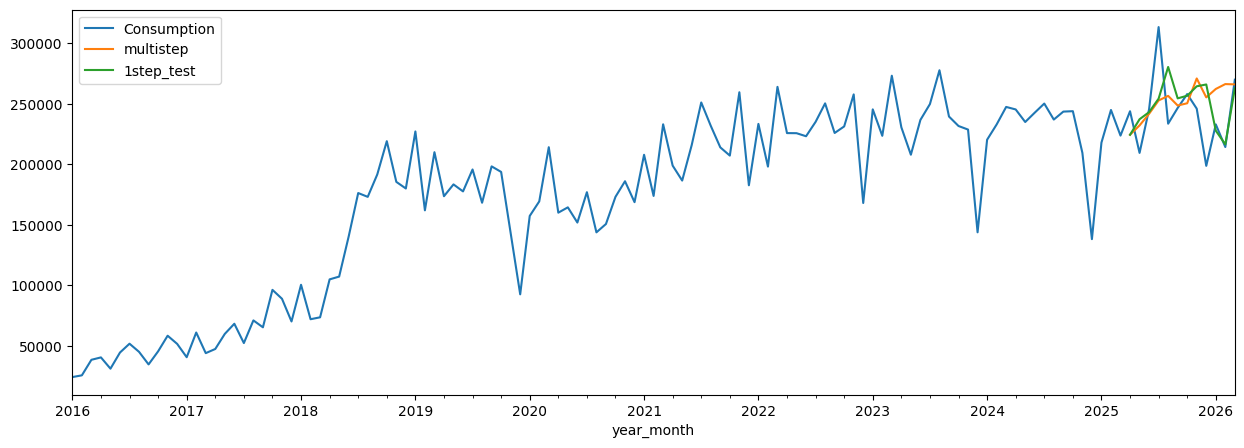

In [123]:
# plot 1-step and multi-step forecast
df[['Consumption', 'multistep', '1step_test']].plot(figsize=(15, 5));

In [124]:
# make multi-output supervised dataset
Tx = T
Ty = Ntest
X = []
Y = []
for t in range(len(series) - Tx - Ty + 1):
  x = series[t:t+Tx]
  X.append(x)
  y = series[t+Tx:t+Tx+Ty]
  Y.append(y)

X = np.array(X).reshape(-1, Tx)
Y = np.array(Y).reshape(-1, Ty)
N = len(X)
print("X.shape", X.shape, "Y.shape", Y.shape)

X.shape (101, 10) Y.shape (101, 12)


In [125]:
Xtrain_m, Ytrain_m = X[:-1], Y[:-1]
Xtest_m, Ytest_m = X[-1:], Y[-1:]

In [126]:
# Basic ANN
i = Input(shape=(Tx,))
x = Dense(32, activation='relu')(i)
x = Dense(Ty)(x)
model = Model(i, x)

In [127]:
model.compile(
  loss='mse',
  optimizer='adam',
)

In [128]:
r = model.fit(
  Xtrain_m,
  Ytrain_m,
  epochs=150,
  validation_data=(Xtest_m, Ytest_m)
)

Epoch 1/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - loss: 1620406400.0000 - val_loss: 1913223808.0000
Epoch 2/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 1574632960.0000 - val_loss: 1903136768.0000
Epoch 3/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 1536926080.0000 - val_loss: 1895314432.0000
Epoch 4/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 1502056448.0000 - val_loss: 1889013760.0000
Epoch 5/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 1469449728.0000 - val_loss: 1883838080.0000
Epoch 6/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 1438782080.0000 - val_loss: 1879660544.0000
Epoch 7/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 1409915008.0000 - val_loss: 1876644224.0000
Epoch 8/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1382695424.0000 - val_loss: 1874516992.0000
Epoch 9/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 1356929152.0000 - val_loss: 1872992896.0000
Epoch 10/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1332501760.0000 - val_l

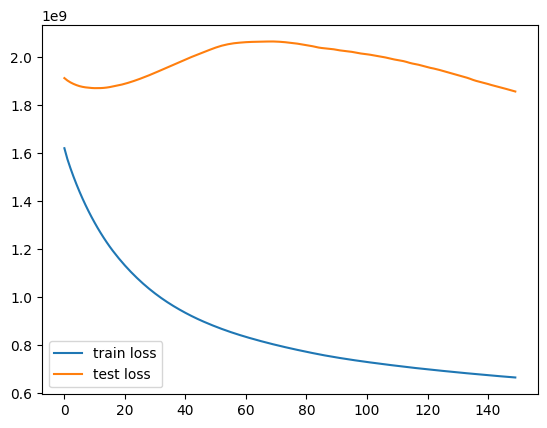

In [129]:
plt.plot(r.history['loss'], label='train loss')
plt.plot(r.history['val_loss'], label='test loss')
plt.legend();

In [130]:
Ptrain = model.predict(Xtrain_m)
Ptest = model.predict(Xtest_m)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


In [131]:
Ptrain.shape, Ptest.shape

((100, 12), (1, 12))

In [132]:
Ptrain = Ptrain[:,0]
Ptest = Ptest[0]

In [133]:
# save multi-output forecast to dataframe
df.loc[test_idx, 'multioutput'] = last_train + \
  np.cumsum(Ptest)

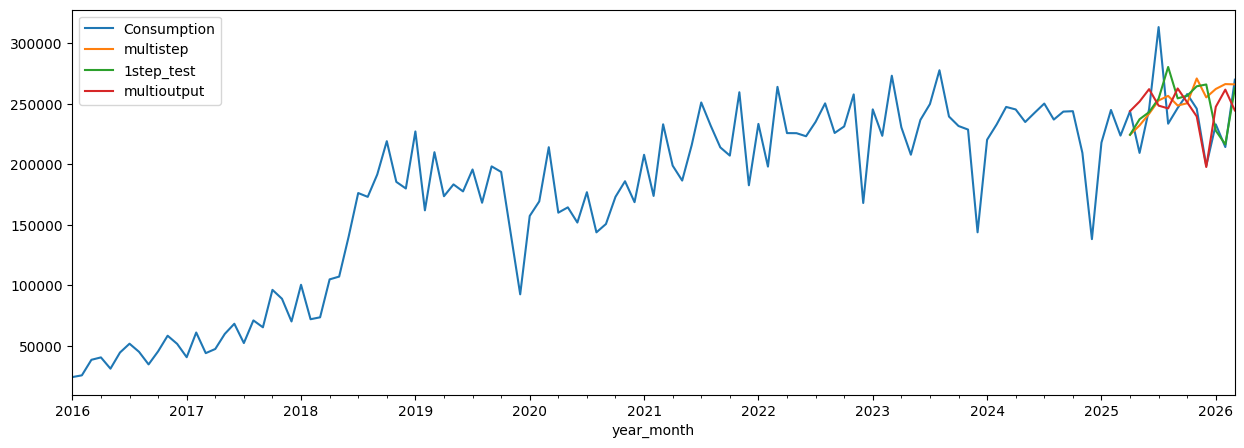

In [134]:
# plot all forecasts
cols = ['Consumption', 'multistep', '1step_test', 'multioutput']
df[cols].plot(figsize=(15, 5));

In [135]:
# MAPE
test_log_pass = df.iloc[-Ntest:]['Consumption']
mape1 = mean_absolute_percentage_error(
    test_log_pass, df.loc[test_idx, 'multistep'])
print("multi-step MAPE:", mape1)
mape2 = mean_absolute_percentage_error(
    test_log_pass, df.loc[test_idx, 'multioutput'])
print("multi-output MAPE:", mape2)

multi-step MAPE: 0.10847172246268211
multi-output MAPE: 0.08602226276318896


# **CNN**

In [136]:
df.head()

,Consumption,DiffConsumption,Diff ANN Train Prediction,Diff ANN Test Prediction,ShiftConsumption,1step_train,1step_test,multistep,multioutput
year_month,,,,,,,,,
2016-01-31,24273,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-02-29,25715,1442.0,NaN,NaN,24273.0,NaN,NaN,NaN,NaN
2016-03-31,38543,12828.0,NaN,NaN,25715.0,NaN,NaN,NaN,NaN
2016-04-30,40524,1981.0,NaN,NaN,38543.0,NaN,NaN,NaN,NaN
2016-05-31,31222,-9302.0,NaN,NaN,40524.0,NaN,NaN,NaN,NaN


In [137]:
df.columns

Index(['Consumption', 'DiffConsumption', 'Diff ANN Train Prediction',
       'Diff ANN Test Prediction', 'ShiftConsumption', '1step_train',
       '1step_test', 'multistep', 'multioutput'],
      dtype='object')

In [138]:
df=df.drop(['Diff ANN Train Prediction',
       'Diff ANN Test Prediction', 'ShiftConsumption', '1step_train',
       '1step_test', 'multistep', 'multioutput'],axis=1)

In [139]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input, GlobalMaxPooling1D
from tensorflow.keras.layers import Conv1D, MaxPooling1D
from tensorflow.keras.models import Model

In [140]:
# CNN
i = Input(shape=(T, 1))
x = Conv1D(16, 3, activation='relu')(i)
x = MaxPooling1D(2)(x)
x = Conv1D(32, 3, activation='relu')(x)
x = GlobalMaxPooling1D()(x)
x = Dense(1)(x)
model = Model(i, x)

In [141]:
model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 10, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 8, 16)          │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 4, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 2, 32)          │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_3          │ (None, 32)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,665 (6.50 KB)

 Trainable params: 1,665 (6.50 KB)

 Non-trainable params: 0 (0.00 B)

In [142]:
model.compile(
  loss='mse',
  optimizer='adam',
)

In [143]:
# CNN
i = Input(shape=(T, 1), dtype=tf.float32)
x = Conv1D(16, 3, activation='relu')(i)
x = MaxPooling1D(2)(x)
x = Conv1D(32, 3, activation='relu')(x)
x = GlobalMaxPooling1D()(x)
x = Dense(1)(x)
model = Model(i, x)

model.compile(
  loss='mse',
  optimizer='adam',
)

Xtrain_cnn = Xtrain.reshape(-1, T, 1).astype(np.float32)
Ytrain_cnn = Ytrain.astype(np.float32)
Xtest_cnn = Xtest.reshape(-1, T, 1).astype(np.float32)
Ytest_cnn = Ytest.astype(np.float32)

r = model.fit(
  Xtrain_cnn,
  Ytrain_cnn,
  epochs=100,
  validation_data=(Xtest_cnn, Ytest_cnn)
)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - loss: 1456094208.0000 - val_loss: 1686024320.0000
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 1273094016.0000 - val_loss: 1589081472.0000
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1228351744.0000 - val_loss: 1598147200.0000
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1221681152.0000 - val_loss: 1613813888.0000
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 1203269376.0000 - val_loss: 1613187456.0000
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1175764480.0000 - val_loss: 1612481152.0000
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1152979968.0000 - val_loss: 1621305728.0000
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1136198016.0000 - val_loss: 1637548032.0000
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1123312128.0000 - val_loss: 1655456768.0000
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1110920576.0000 - val_l

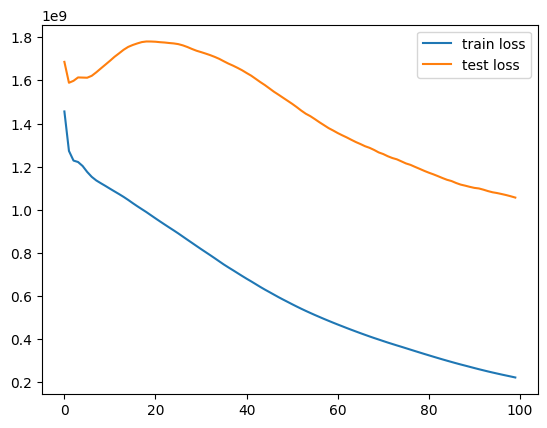

In [144]:
plt.plot(r.history['loss'], label='train loss')
plt.plot(r.history['val_loss'], label='test loss')
plt.legend();

In [145]:
train_idx[:T+1] = False # first T+1 values are not predictable

In [146]:
Ptrain = model.predict(Xtrain_cnn).flatten()
Ptest = model.predict(Xtest_cnn).flatten()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


In [147]:
# Store diff predictions
df.loc[train_idx, 'Diff Train Prediction'] = Ptrain
df.loc[test_idx, 'Diff Test Prediction'] = Ptest

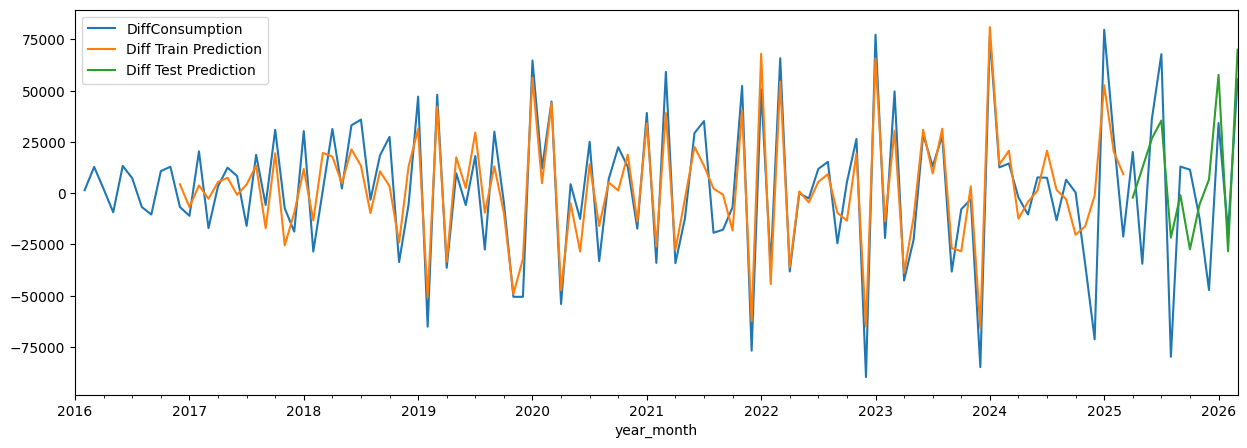

In [148]:
cols = ['DiffConsumption',
        'Diff Train Prediction',
        'Diff Test Prediction']
df[cols].plot(figsize=(15, 5));

In [149]:
# Needed to compute un-differenced predictions
df['ShiftConsumption'] = df['Consumption'].shift(1)
prev = df['ShiftConsumption']

In [150]:
# Last-known train value
last_train = train.iloc[-1]['Consumption']

In [151]:
# 1-step forecast
df.loc[train_idx, '1step_train'] = prev[train_idx] + Ptrain
df.loc[test_idx, '1step_test'] = prev[test_idx] + Ptest

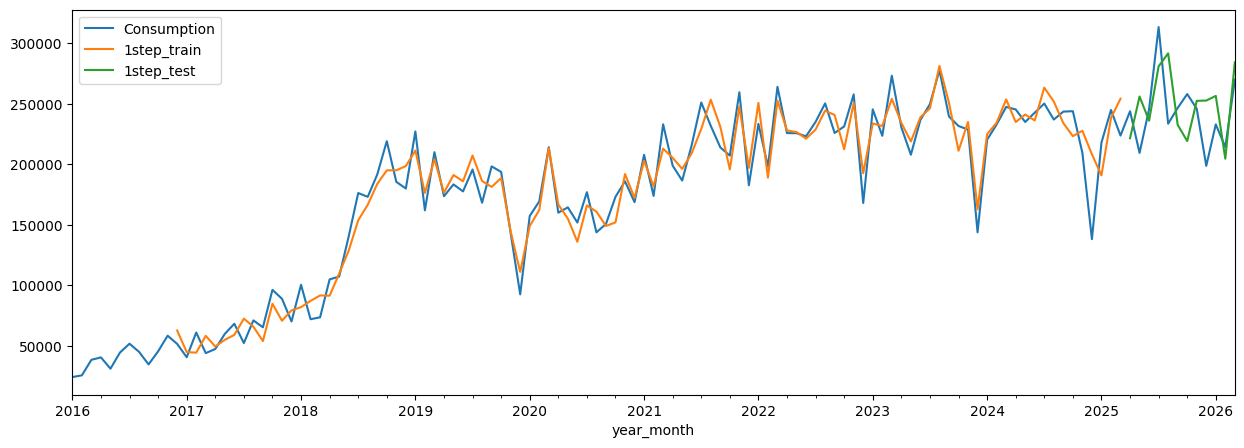

In [152]:
# plot 1-step forecast
df[['Consumption', '1step_train', '1step_test']].plot(figsize=(15, 5));

In [153]:
# multi-step forecast
multistep_predictions = []

# first test input
last_x = Xtest[0]

while len(multistep_predictions) < Ntest:
  p = model.predict(last_x.reshape(1, -1, 1))[0]

  # update the predictions list
  multistep_predictions.append(p)

  # make the new input
  last_x = np.roll(last_x, -1)
  last_x[-1] = p

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


In [154]:
# save multi-step forecast to dataframe
df.loc[test_idx, 'multistep'] = last_train + np.cumsum(multistep_predictions)

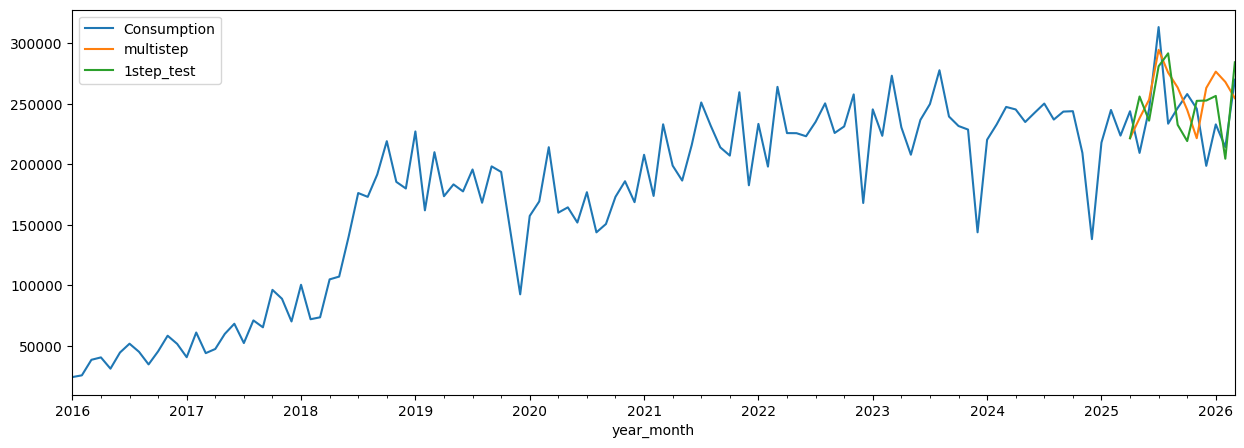

In [155]:
# plot 1-step and multi-step forecast
df[['Consumption', 'multistep', '1step_test']].plot(figsize=(15, 5));

In [156]:
# make multi-output supervised dataset
Tx = T
Ty = Ntest
X = []
Y = []
for t in range(len(series) - Tx - Ty + 1):
  x = series[t:t+Tx]
  X.append(x)
  y = series[t+Tx:t+Tx+Ty]
  Y.append(y)

X = np.array(X).reshape(-1, Tx, 1)
Y = np.array(Y).reshape(-1, Ty)
N = len(X)
print("X.shape", X.shape, "Y.shape", Y.shape)

X.shape (101, 10, 1) Y.shape (101, 12)


In [157]:
Xtrain_m, Ytrain_m = X[:-1], Y[:-1]
Xtest_m, Ytest_m = X[-1:], Y[-1:]

In [158]:
# CNN
i = Input(shape=(Tx, 1))
x = Conv1D(16, 3, activation='relu')(i)
x = MaxPooling1D(2)(x)
x = Conv1D(32, 3, activation='relu')(x)
x = GlobalMaxPooling1D()(x)
x = Dense(Ty)(x)
model = Model(i, x)

In [159]:
model.compile(
  loss='mse',
  optimizer='adam',
)

In [160]:
r = model.fit(
  Xtrain_m,
  Ytrain_m,
  epochs=200,
  validation_data=(Xtest_m, Ytest_m)
)

Epoch 1/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - loss: 1335664000.0000 - val_loss: 2410735360.0000
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 1316674304.0000 - val_loss: 2359096576.0000
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1304756992.0000 - val_loss: 2316517120.0000
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1295687552.0000 - val_loss: 2287324416.0000
Epoch 5/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1288465920.0000 - val_loss: 2265967872.0000
Epoch 6/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 1282141440.0000 - val_loss: 2250291200.0000
Epoch 7/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1276204032.0000 - val_loss: 2239438592.0000
Epoch 8/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 1270694016.0000 - val_loss: 2230125056.0000
Epoch 9/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 1265454592.0000 - val_loss: 2225808640.0000
Epoch 10/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1260264576.0000 - val_l

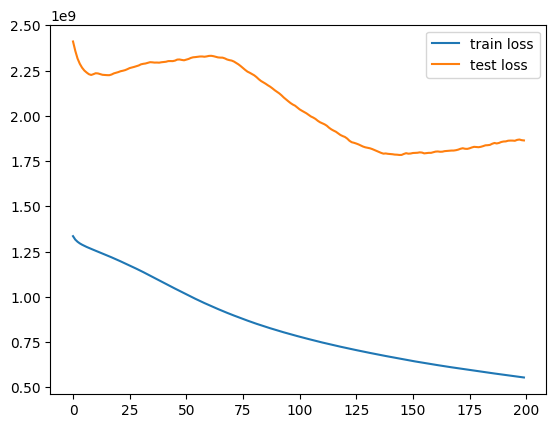

In [161]:
plt.plot(r.history['loss'], label='train loss')
plt.plot(r.history['val_loss'], label='test loss')
plt.legend();

In [162]:
Ptrain = model.predict(Xtrain_m)
Ptest = model.predict(Xtest_m)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


In [163]:
Ptrain.shape, Ptest.shape

((100, 12), (1, 12))

In [164]:
Ptrain = Ptrain[:,0]
Ptest = Ptest[0]

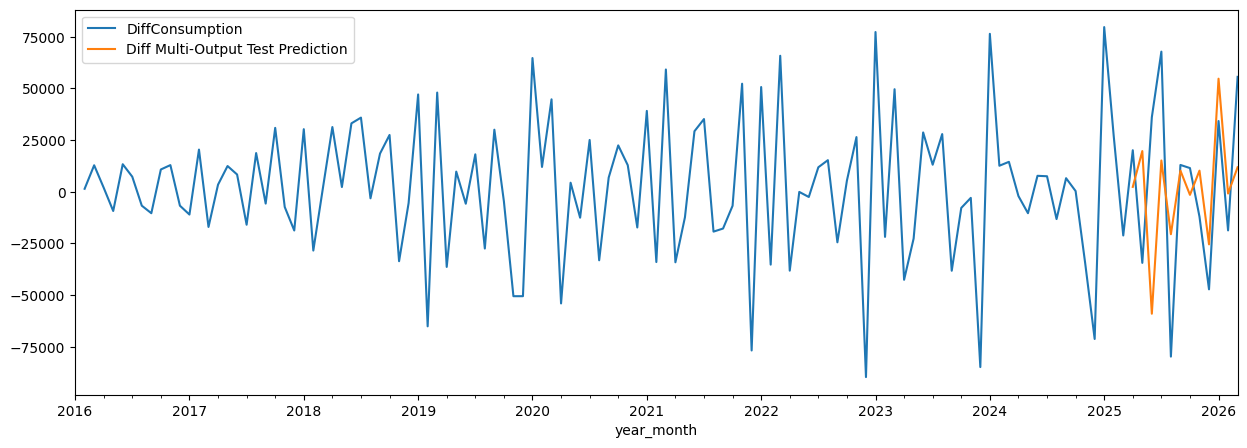

In [165]:
df.loc[test_idx, 'Diff Multi-Output Test Prediction'] = Ptest
cols = ['DiffConsumption', 'Diff Multi-Output Test Prediction']
df[cols].plot(figsize=(15, 5));

In [166]:
# save multi-output forecast to dataframe
df.loc[test_idx, 'multioutput'] = last_train + \
  np.cumsum(Ptest)

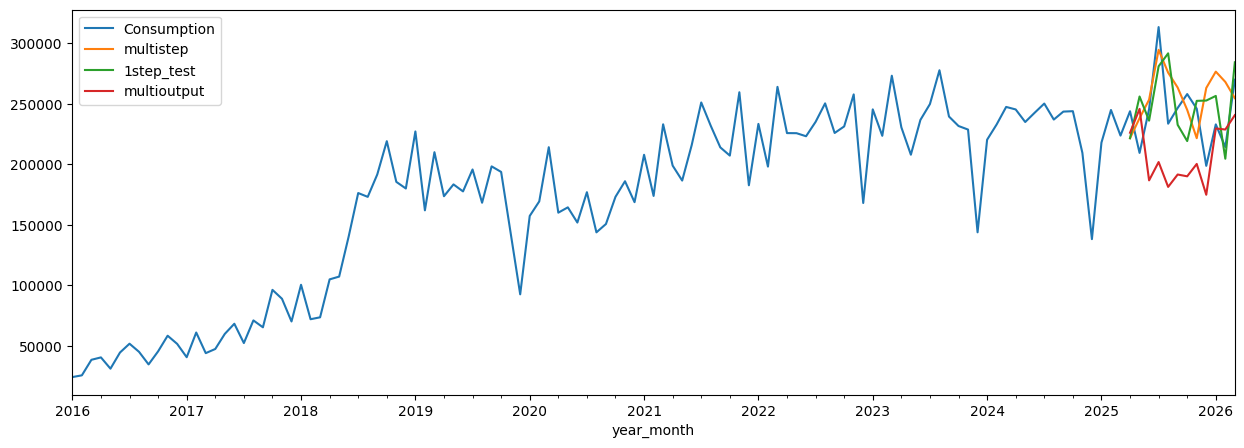

In [167]:
# plot all forecasts
cols = ['Consumption', 'multistep', '1step_test', 'multioutput']
df[cols].plot(figsize=(15, 5));

In [168]:
# MAPE
test_log_pass = df.iloc[-Ntest:]['Consumption']
mape1 = mean_absolute_percentage_error(
    test_log_pass, df.loc[test_idx, 'multistep'])
print("multi-step MAPE:", mape1)
mape2 = mean_absolute_percentage_error(
    test_log_pass, df.loc[test_idx, 'multioutput'])
print("multi-output MAPE:", mape2)

multi-step MAPE: 0.1281086024813936
multi-output MAPE: 0.1706217876057479


## **Auto-Arima**



In [169]:
df.head()

,Consumption,DiffConsumption,Diff Train Prediction,Diff Test Prediction,ShiftConsumption,1step_train,1step_test,multistep,Diff Multi-Output Test Prediction,multioutput
year_month,,,,,,,,,,
2016-01-31,24273,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-02-29,25715,1442.0,NaN,NaN,24273.0,NaN,NaN,NaN,NaN,NaN
2016-03-31,38543,12828.0,NaN,NaN,25715.0,NaN,NaN,NaN,NaN,NaN
2016-04-30,40524,1981.0,NaN,NaN,38543.0,NaN,NaN,NaN,NaN,NaN
2016-05-31,31222,-9302.0,NaN,NaN,40524.0,NaN,NaN,NaN,NaN,NaN


In [170]:
df.columns

Index(['Consumption', 'DiffConsumption', 'Diff Train Prediction',
       'Diff Test Prediction', 'ShiftConsumption', '1step_train', '1step_test',
       'multistep', 'Diff Multi-Output Test Prediction', 'multioutput'],
      dtype='object')

In [171]:
df=df.drop(['DiffConsumption', 'Diff Train Prediction',
       'Diff Test Prediction', 'ShiftConsumption', '1step_train', '1step_test',
       'multistep', 'Diff Multi-Output Test Prediction', 'multioutput'],axis=1)

In [172]:
!pip install pmdarima

In [173]:
import pmdarima as pm

In [174]:
model = pm.auto_arima(train['Consumption'],
                      trace=True,
                      suppress_warnings=True,
                      seasonal=True, m=12)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=2555.235, Time=1.31 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=2606.270, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=2550.973, Time=0.28 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=2555.537, Time=0.53 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=2604.602, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=2581.281, Time=0.06 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=2552.768, Time=1.02 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=2552.904, Time=0.61 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=2558.436, Time=0.43 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=2554.470, Time=1.97 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=2564.976, Time=0.26 sec
 ARIMA(2,1,0)(1,0,0)[12] intercept   : AIC=2551.368, Time=0.55 sec
 ARIMA(1,1,1)(1,0,0)[12] intercept   : AIC=2552.035, Time=0.52 sec
 ARIMA(0,1,1)(1,0,0)[12] intercept   : AIC=2550.707, Time=0.63 sec
 ARIMA(0,1,1)(0,0,0

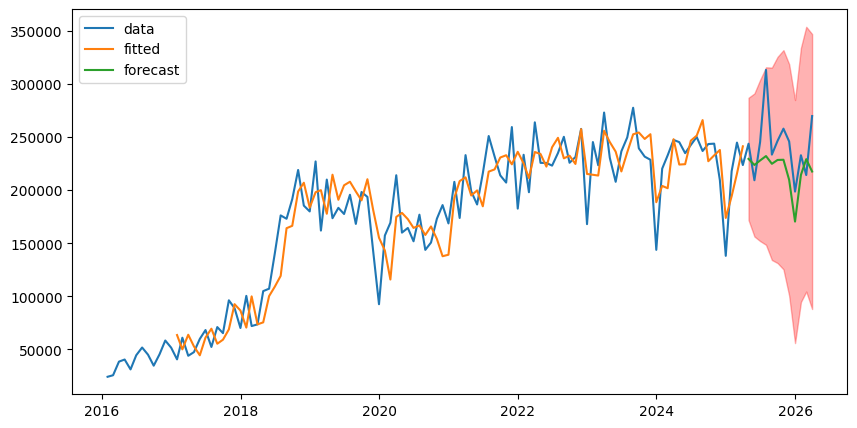

In [175]:
# Since the model is seasonal, we won't plot or predict the first 12
# values (since pmdarima will set them to 0)
train_pred = model.predict_in_sample(start=12, end=-1)
test_pred, confint = model.predict(n_periods=Ntest, return_conf_int=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df.index, df['Consumption'], label='data')
ax.plot(train.index[12:], train_pred, label='fitted')
ax.plot(test.index, test_pred, label='forecast')
ax.fill_between(test.index, \
                confint[:,0], confint[:,1], \
                color='red', alpha=0.3)
ax.legend();

In [176]:
mean_absolute_error(test['Consumption'], test_pred)

27793.01606633789

In [177]:
mean_absolute_percentage_error(test['Consumption'], test_pred)

0.10948962661224532

In [ ]:
mean_squared_error(test['Consumption'], test_pred,squared=False)

In [178]:
import math
math.sqrt(mean_squared_error(test['Consumption'], test_pred))

34116.86451657382

In [179]:
# Best non-seasonal model
model = pm.auto_arima(train['Consumption'],
                      trace=True,
                      max_p=12, max_q=2, max_order=14,
                      suppress_warnings=True,
                      stepwise=False,
                      seasonal=False)

 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=2606.270, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=2575.237, Time=0.07 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=2578.557, Time=0.12 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=2581.281, Time=0.04 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=2576.578, Time=0.11 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=2571.666, Time=0.29 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=2580.723, Time=0.05 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=2578.942, Time=0.41 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=2572.945, Time=0.80 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=2576.360, Time=0.15 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=2577.205, Time=0.30 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=2579.537, Time=0.49 sec
 ARIMA(4,1,0)(0,0,0)[0] intercept   : AIC=2577.125, Time=0.35 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=2579.066, Time=0.51 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=2576.212, Time=1.10 sec
 ARIMA(5,1

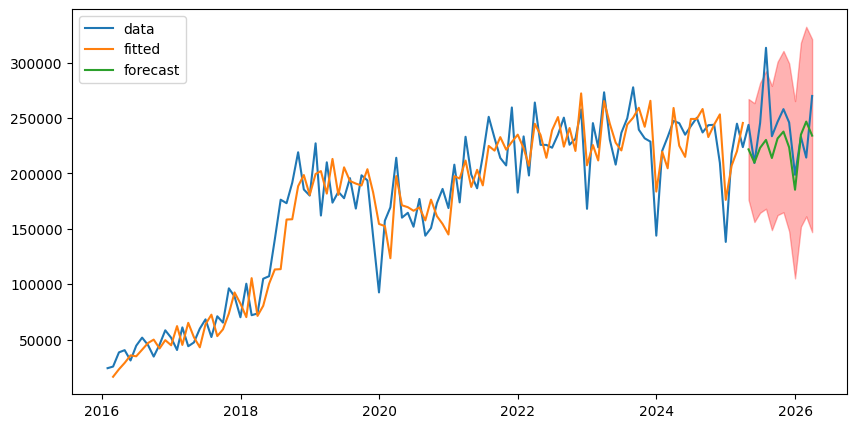

In [180]:
train_pred = model.predict_in_sample(start=1, end=-1)
test_pred, confint = model.predict(n_periods=Ntest, return_conf_int=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df.index, df['Consumption'], label='data')
ax.plot(train.index[1:], train_pred, label='fitted')
ax.plot(test.index, test_pred, label='forecast')
ax.fill_between(test.index, \
                confint[:,0], confint[:,1], \
                color='red', alpha=0.3)
ax.legend();

In [181]:
mean_absolute_error(test['Consumption'], test_pred)

24090.491404110013

In [182]:
mean_absolute_percentage_error(test['Consumption'], test_pred)

0.09370082729210212

In [183]:
math.sqrt(mean_squared_error(test['Consumption'], test_pred))

31548.91275618338